## SBI Example: Infer Throwing Angle from Distance
adapted from Deistler et al. (2025)


In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from sbi.inference import NPE
from sbi.utils import BoxUniform

/home/jakob/miniconda3/envs/sbi/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


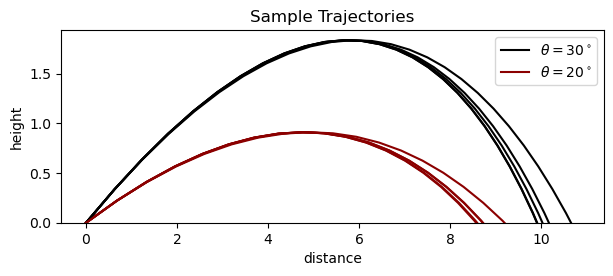

In [2]:
# -------------------------
# Parameters
# -------------------------

gravity = 9.81
strength = 15.0
friction = 0.8
wind = 0.8
dt = 0.05


# -------------------------
# Simulator
# -------------------------

def simulate(angle):
    # start values
    xs = [0.0]
    ys = [0.0]
    angle = angle / 180 * np.pi

    # throw
    dx = np.cos(angle) * strength
    dy = np.sqrt(strength**2 - dx**2)

    # random wind
    exp_dist = torch.distributions.Exponential(1).sample().numpy()
    wind_rand = wind * exp_dist

    # steps
    for i in range(10_000):
        x, y, dx, dy = step(xs[-1], ys[-1], dx, dy, dt, wind_rand)
        xs.append(x)
        ys.append(y)
        if i > 1 and ys[-1] < 0:
            break
    return xs, ys

# Step Function
def step(x, y, dx, dy, dt, wind_rand):#
    # calc friction effect
    friction_x = friction * dx
    friction_y = friction * dy

    # y-direction
    ddy = -gravity - friction_y
    dy += ddy * dt

    # x-direction
    ddx = wind_rand - friction_x
    dx += ddx * dt

    return x + dx * dt, y + dy * dt, dx, dy

# Calc Throw Distance from Trajectory
def throw_distance(xs, ys):
    frac = 1 - (ys[-1] / (ys[-1] - ys[-2]))
    dist = frac * (xs[-1] - xs[-2]) + xs[-2]
    return dist


# -------------------------
# Plot of Trajectories
# -------------------------

plt.figure(figsize=(7,2.5))
theta1 = 30
theta2 = 20
plt.title('Sample Trajectories')
plt.plot(*simulate(theta1), c='k', label=rf'$\theta = {theta1}^\circ$')
plt.plot(*simulate(theta2), c='darkred', label=rf'$\theta = {theta2}^\circ$')
for i in range(4):
    plt.plot(*simulate(theta1), c='k')
    plt.plot(*simulate(theta2), c='darkred')
plt.ylabel('height')
plt.xlabel('distance')
plt.ylim(0)
plt.legend()
plt.show()

/tmp/ipykernel_223738/3357321660.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dx = np.cos(angle) * strength
/tmp/ipykernel_223738/3357321660.py:24: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dy = np.sqrt(strength**2 - dx**2)


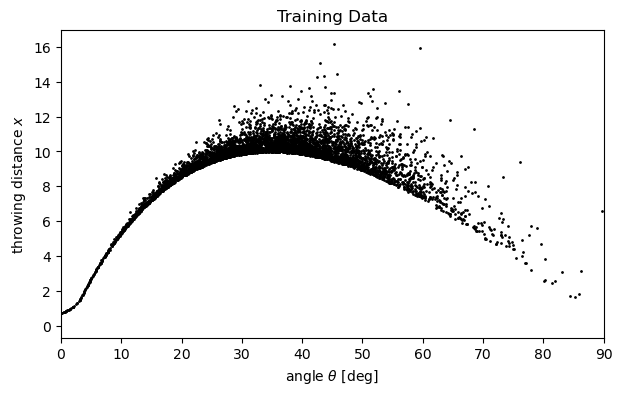

In [3]:
# -------------------------
# Gaussian Prior
# -------------------------

mean = torch.tensor([35.0]) # angle in degrees
cov = 15**2 * torch.eye(1)
prior = torch.distributions.MultivariateNormal(mean, cov)
# prior = BoxUniform(torch.tensor([0]), torch.tensor([90]))


# -------------------------
# Generate training data
# -------------------------

num_simulations = 5_000

theta = prior.sample((num_simulations,))
x = torch.stack([throw_distance(*simulate(t)) for t in theta])


# -------------------------
# Plot training data
# -------------------------

plt.figure(figsize=(7, 4))
plt.title('Training Data')
plt.scatter(theta, x, s=1.0, c='black')
plt.xlabel(r'angle $\theta$ [deg]')
plt.ylabel(r'throwing distance $x$')
plt.xlim(0, 90)
plt.show()

In [4]:
# -------------------------
# Train NPE
# -------------------------

inference = NPE(prior=prior, density_estimator="nsf") # neural spline flow
inference.append_simulations(theta, x)

density_estimator = inference.train()

posterior = inference.build_posterior(
    density_estimator
)

 Neural network successfully converged after 65 epochs.

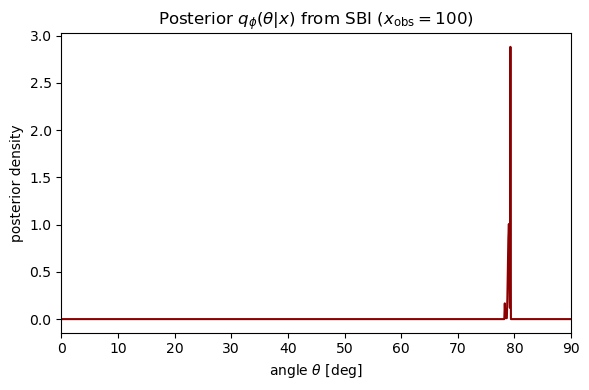

In [8]:
# -------------------------
# Observation
# -------------------------

x_obs = 100

# sample from posterior
theta_axis = torch.linspace(0, 90, 1000)
probs = torch.exp(posterior.log_prob(theta_axis.unsqueeze(1), x=x_obs))

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(6, 4))
plt.title(rf'Posterior $q_\phi(\theta|x)$ from SBI ($x_\text{{obs}} = {x_obs}$)')

plt.plot(theta_axis, probs, color="darkred")

plt.xlabel(r"angle $\theta$ [deg]")
plt.ylabel(r"posterior density")
plt.xlim(0,90)

plt.tight_layout()
plt.show()